# FAIRyMAGs + MGnify + Magneto + Ref

## Add output form this workflow: https://usegalaxy.eu/u/paulzierep/w/drep-fairymags-benchmark
## Example History: https://usegalaxy.eu/u/paulzierep/h/drep-fairymags-benchmark

In [84]:
#!/usr/bin/env python3

from bioblend.galaxy import GalaxyInstance
import pandas as pd
import io
import sys
import os

# === CONFIGURATION ===
GALAXY_URL = "https://usegalaxy.eu"
API_KEY = os.environ.get("GALAXY_API_KEY")

if not API_KEY:
    sys.exit("GALAXY_API_KEY environment variable not set")

# --- Connect to Galaxy ---
gi = GalaxyInstance(url=GALAXY_URL, key=API_KEY)

###################
# Get the cluser file
###################

DATASET_ID = "26c75dcccb616ac8ca5e62a54193a7e3"  # Cdb Clustering result

# --- Download dataset content into memory ---
content = gi.datasets.download_dataset(DATASET_ID, use_default_filename=False)

# --- Try to load as CSV, fallback to TSV ---
try:
    cdb = pd.read_csv(io.BytesIO(content), comment="#")
except Exception:
    cdb = pd.read_csv(io.BytesIO(content), sep="\t", comment="#")

print(f"✅ Loaded dataset {DATASET_ID} with shape {cdb.shape}")
print(cdb.head())
print(cdb)

###################
# Get the quality file
###################

DATASET_ID = "26c75dcccb616ac8102f4141cc9f320b"  # checkm2 for all genomes

# --- Download dataset content into memory ---
content = gi.datasets.download_dataset(DATASET_ID, use_default_filename=False)

# --- Try to load as CSV, fallback to TSV ---
checkm2 = pd.read_csv(io.BytesIO(content), sep="\t", comment="#")

print(f"✅ Loaded dataset {DATASET_ID} with shape {checkm2.shape}")
print(checkm2.head())


✅ Loaded dataset 26c75dcccb616ac8ca5e62a54193a7e3 with shape (1032, 6)
                                              genome secondary_cluster  \
0       RNODE_577_length_7056_cov_38.11425_ref.fasta               1_0   
1       RNODE_578_length_7436_cov_10.94682_ref.fasta               2_0   
2         GCF_000001735.4_TAIR10.1_genomic_ref.fasta               3_0   
3  Umbelopsis_autotrophica_MPI-SW4-AT-0611.contig...               4_0   
4  Talaromyces_verruculosus_MPI-SP2-AT-0411.conti...               5_0   

   threshold cluster_method comparison_algorithm  primary_cluster  
0       0.05        average                ANImf                1  
1       0.05        average                ANImf                2  
2       0.05        average                ANImf                3  
3       0.05        average                ANImf                4  
4       0.05        average                ANImf                5  
                                                 genome secondary_cluster  \

In [44]:
checkm2

,Name,Completeness,Contamination,Completeness_Model_Used,Translation_Table_Used,Coding_Density,Contig_N50,Average_Gene_Length,Genome_Size,GC_Content,Total_Coding_Sequences,Total_Contigs,Max_Contig_Length,Additional_Notes
0,1120950.PRJNA169810_ref,95.28,3.86,Gradient Boost (General Model),11,0.869,119977,310.358672,7983713,0.68,7472,127,554948,NaN
1,1120967.PRJNA185542_ref,100.00,0.11,Neural Network (Specific Model),11,0.887,212985,344.429807,5781275,0.48,4972,61,536071,NaN
2,1121288.PRJNA188854_ref,99.98,0.16,Neural Network (Specific Model),11,0.895,327052,332.556385,2981117,0.41,2678,21,469605,NaN
3,1121335.PRJNA181307_ref,100.00,0.68,Neural Network (Specific Model),11,0.875,2974379,335.144950,2974379,0.42,2594,1,2974379,NaN
4,1121346.PRJNA182399_ref,99.99,0.68,Neural Network (Specific Model),11,0.863,117391,310.102355,4476185,0.57,4162,102,272175,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1347,anonymous_reads_66__name_anonymous_reads.fq_bi...,38.49,2.76,Neural Network (Specific Model),11,0.880,3236,225.205134,3700952,0.66,4831,1211,11465,NaN
1348,anonymous_reads_82__name_anonymous_reads.fq_bi...,59.24,6.08,Neural Network (Specific Model),11,0.889,3862,250.408156,4470086,0.67,5297,1240,13799,NaN
1349,bin_concoct_SASB_rhimgCAMI2-sample-7.20_sub_ma...,3.23,0.49,Neural Network (Specific Model),11,0.824,2304,243.077381,148286,0.60,168,60,8637,NaN
1350,sample_runs_0_concoct_62_mgnify,100.00,1.40,Neural Network (Specific Model),11,0.902,340805,366.294314,8025228,0.64,6595,50,592832,NaN


In [79]:
MIN_COMPLETENESS = 75
MAX_CONTAMINATION = 25

hq_genomes = checkm2.loc[
    (checkm2["Completeness"] >= MIN_COMPLETENESS) &
    (checkm2["Contamination"] <= MAX_CONTAMINATION),
    "Name"
].unique()

print(f"✅ High-quality genomes: {len(hq_genomes)}")

✅ High-quality genomes: 559


In [80]:
cdb["genome"] = cdb["genome"].str.replace(r"\.fasta$", "", regex=True)
cdb

,genome,secondary_cluster,threshold,cluster_method,comparison_algorithm,primary_cluster
0,RNODE_577_length_7056_cov_38.11425_ref,1_0,0.05,average,ANImf,1
1,RNODE_578_length_7436_cov_10.94682_ref,2_0,0.05,average,ANImf,2
2,GCF_000001735.4_TAIR10.1_genomic_ref,3_0,0.05,average,ANImf,3
3,Umbelopsis_autotrophica_MPI-SW4-AT-0611.contig...,4_0,0.05,average,ANImf,4
4,Talaromyces_verruculosus_MPI-SP2-AT-0411.conti...,5_0,0.05,average,ANImf,5
...,...,...,...,...,...,...
1027,RNODE_63_length_9116_cov_7.17902_ref,731_0,0.05,average,ANImf,731
1028,RNODE_80_length_5133_cov_7.08687_ref,732_0,0.05,average,ANImf,732
1029,RNODE_83_length_6134_cov_3.71057_ref,733_0,0.05,average,ANImf,733
1030,RNODE_87_length_5673_cov_23.00212_ref,734_0,0.05,average,ANImf,734


In [81]:
cdb_filtered = cdb[cdb["genome"].isin(hq_genomes)].copy()

print(f"✅ Filtered CDB shape: {cdb_filtered.shape}")
print(cdb_filtered.head())

✅ Filtered CDB shape: (559, 6)
                    genome secondary_cluster  threshold cluster_method  \
5  1345695.PRJNA217481_ref               6_0       0.05        average   
6    290402.PRJNA12637_ref               7_0       0.05        average   
7  1121342.PRJNA194074_ref               8_0       0.05        average   
8   1041930.PRJNA73221_ref               9_0       0.05        average   
9  1120985.PRJNA188816_ref              10_0       0.05        average   

  comparison_algorithm  primary_cluster  
5                ANImf                6  
6                ANImf                7  
7                ANImf                8  
8                ANImf                9  
9                ANImf               10  


source
True Genomes    437
MAGNETO          56
MGnify           36
FAIRyMAGs        30
Name: count, dtype: int64
source
True Genomes    385
FAIRyMAGs        30
MAGNETO          10
MGnify           36
dtype: int64


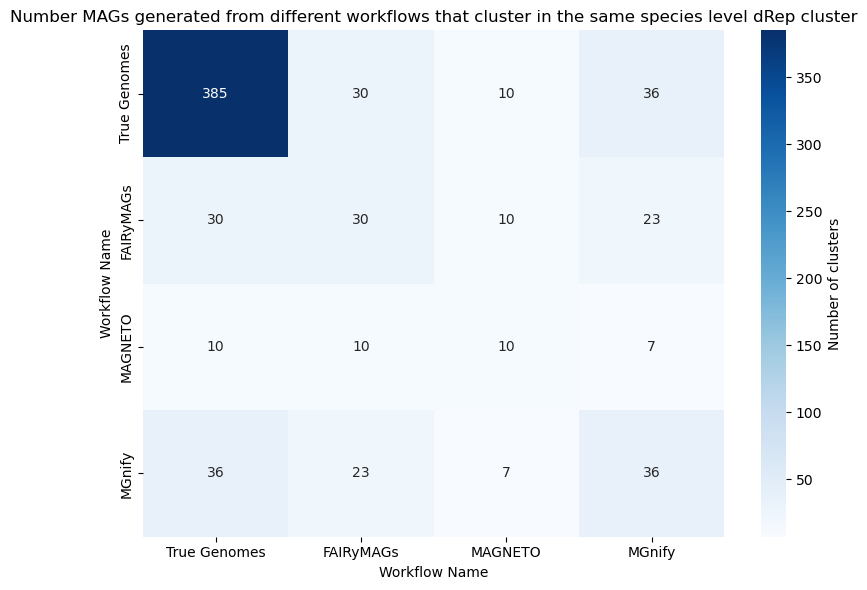

In [82]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Assume df has 'genome' and 'source' columns
# If not, use your get_source() logic:
df = cdb_filtered.copy()  # your dataframe

def get_source(name):
    if name.endswith('_ref'):
        return 'True Genomes'
    elif '_fairymags' in name:
        return 'FAIRyMAGs'
    elif '_magneto' in name:
        return 'MAGNETO'
    elif '_mgnify' in name:
        return 'MGnify'
    else:
        return 'other'

df['source'] = df['genome'].apply(get_source)

# Number of genomes per group
print(df['source'].value_counts())

# Step 1: Count genomes per cluster per source
per_cluster = df.groupby(['secondary_cluster', 'source']).size().unstack(fill_value=0)

# Step 2: Convert to boolean presence (1 if at least one genome)
presence = per_cluster[['True Genomes', 'FAIRyMAGs', 'MAGNETO', 'MGnify']] > 0

# Number of dereplicated genomes per group
print(presence.sum())

# Step 3: Initialize empty overlap matrix
sources = presence.columns
overlap_matrix = pd.DataFrame(0, index=sources, columns=sources)

# Step 4: Count number of clusters shared between each pair
for i in sources:
    for j in sources:
        overlap_matrix.loc[i, j] = ((presence[i]) & (presence[j])).sum()

# Step 5: Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(overlap_matrix, annot=True, fmt="d", cmap="Blues", cbar_kws={'label': 'Number of clusters'})
plt.title('Number MAGs generated from different workflows that cluster in the same species level dRep cluster')
plt.ylabel('Workflow Name')
plt.xlabel('Workflow Name')
plt.tight_layout()
plt.show()


In [86]:
# Clusters without True Genomes
no_ref = ~presence['True Genomes']

# Count clusters per source that do not include a reference genome
no_ref_counts = {
    src: (presence[src] & no_ref).sum()
    for src in ['FAIRyMAGs', 'MAGNETO', 'MGnify']
}

no_ref_counts = pd.Series(no_ref_counts, name="Clusters without reference")

print("\n❌ Clusters NOT clustering with True Genomes:")
print(no_ref_counts)

total_clusters = presence[['FAIRyMAGs', 'MAGNETO', 'MGnify']].sum()
summary = pd.DataFrame({
    "Total clusters": total_clusters,
    "Clusters without reference": no_ref_counts,
    "Fraction without reference": no_ref_counts / total_clusters
})

print("\n📊 Summary per workflow:")
print(summary)


❌ Clusters NOT clustering with True Genomes:
FAIRyMAGs    0
MAGNETO      0
MGnify       0
Name: Clusters without reference, dtype: int64

📊 Summary per workflow:
           Total clusters  Clusters without reference  \
FAIRyMAGs              30                           0   
MAGNETO                10                           0   
MGnify                 36                           0   

           Fraction without reference  
FAIRyMAGs                         0.0  
MAGNETO                           0.0  
MGnify                            0.0  
